**Table of contents**<a id='toc0_'></a>    
- [Data & Setup](#toc1_)    
  - [Setup](#toc1_1_)    
  - [Downlowading data](#toc1_2_)    
  - [Datasets](#toc1_3_)    
- [Utils: plot loss and compare patterns (candles) functions](#toc2_)    
- [Model, training and testing 1](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

Are patterns in charts real? If so, could a model learn them, and represent them in a more suitable manner? For instance: pattern -> $[0,1]^{\text{latent\_dim}}$.

Since _chartists_ base their patterns on drawing lines, the activation functions will always be `ReLU`s.

As default sequence length (number of candles), the default sequence length is **24 daily** (`seq_len = 24`, `PERIOD="1d"`) candles, which roughly corresponds to one trading month in markets that are not open every day.

**Proposal for further experiments**:
- **Data augmentation** moving the price. Since what matters are the patterns, moving a 
    price up +10 is a viable data-augmentation technique.
- **Adversary attacks with FGSM**: slight modifications on prices should not mean a big difference in the pattern. 
- **Modify the loss**, so the OHLC values are consistant. For instance: if Low > Open > Close > High, 
    the error should signal an inconsistent value. 

# <a id='toc1_'></a>[Data & Setup](#toc0_)

Important variables and data structures resultant from this section:

- `TICKERS` - Symbols of the prices. By default some ETF's symbols.
- `FEATURES` - Characteristics to use. By default Open, High, Low, Close (in that order).
- `DEVICE` - cpu or gpu
  
- `tickers_dfs: dict[str, pd.DataFrame]` - Dictionary mapping each 
    ticker symbol to its corresponding DataFrame.
- `train_dataset`
- `val_dataset`
- `test_dataset`

## <a id='toc1_1_'></a>[Setup](#toc0_)

In [ ]:
# GLOBAL PARAMETERS ALONG THE NOTEBOOK

import torch
import yfinance as yf
import pandas as pd
from pathlib import Path
from datetime import datetime

START_DATE = "2000-01-01"
END_DATE = datetime.now().date()

SEED = 1234 # seed for random generators

# ETF Tickers
TICKERS = ["SPY", "QQQ", "IWM", "DIA",
           "VTI", "VEA", "EEM", "GLD", "TLT", "XLF"]

PERIOD = "1d"

N_CANDLES = 24

FEATURES = ["Open", "High", "Low", "Close"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

## <a id='toc1_2_'></a>[Downlowading data](#toc0_)

In [2]:
from typing import cast

df_tickers = yf.download(
    TICKERS,
    start=START_DATE,
    auto_adjust=True,
    end=END_DATE
)

if df_tickers is None:
    raise RuntimeError("The dataframe was not properly downloaded")
else:
    df_tickers = cast(pd.DataFrame, df_tickers) # For type hints
    
df_tickers = df_tickers.dropna()

tickers_dfs:dict[str, pd.DataFrame] = {}
for t in TICKERS:
    if type(df_tickers.xs(t, level=1, axis=1)) == pd.DataFrame:
        tickers_dfs[t] = cast(pd.DataFrame, df_tickers.xs(t, level=1, axis=1))

[*********************100%***********************]  10 of 10 completed


## <a id='toc1_3_'></a>[Datasets](#toc0_)

DataLoaders to be created before training loop with the proper **batch_size**.

In [3]:
from TickerDataset import TickerDataset
from torch.utils.data import ConcatDataset
from torch.utils.data import random_split

tickers_datasets = {}
for t in TICKERS:
  tickers_datasets[t] = TickerDataset(
    df_ticker=tickers_dfs[t],
    n_candles=N_CANDLES,
    features=FEATURES,
    device=DEVICE
  )

all_tickers_dataset = ConcatDataset(
    list(tickers_datasets.values())
)

N = len(all_tickers_dataset)

train_size = int(0.70 * N)
val_size = int(0.15 * N)
test_size = N - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    all_tickers_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# <a id='toc2_'></a>[Utils: plot loss and compare patterns (candles) functions](#toc0_)

In [4]:
import matplotlib.pyplot as plt

def plot_loss(loss_training, loss_val=None):
    """ Plots the training loss and, optionally, the validation loss. 
    
    Parameters
    ---------- 
    loss_training : sequence 
        Training loss for each epoch. 
    loss_val : sequence, optional 
        Validation loss for each epoch. 
        Must have the same length as loss_training.
    """

    if loss_val is not None and len(loss_val) != len(loss_training):
        raise ValueError(
            "loss_val must have same length as loss_training. "
            f"len(loss_training)={len(loss_training)}, "
            f"len(loss_val)={len(loss_val)}."
        )

    epochs = range(1, len(loss_training) + 1)

    plt.figure(figsize=(8, 4))

    plt.plot(
        epochs,
        loss_training,
        label="training loss"
    )

    if loss_val is not None:
        plt.plot(
            epochs,
            loss_val,
            label="validation loss"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Autoencoder training")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import pandas as pd
import mplfinance as mpf
import random


def plot_candles(ohlc: list[list[float]],
                 dates: pd.DatetimeIndex):
    """Plot OHLC candlesticks using the provided date index.

    Parameters
    ----------
    ohlc : list[list[float]] 
        List of candles, where each candle contains four values: Open, High, Low, and Close. 
    dates : pd.DatetimeIndex 
        Date index corresponding to the OHLC data. Must have the same length as ohlc. 
    """

    if len(dates) != len(ohlc):
        raise ValueError(
            "The date index must have the same length as ohlc. "
            f"len(dates)={len(dates)}, len(ohlc)={len(ohlc)}."
        )

    df = pd.DataFrame(
        ohlc,
        columns=["Open", "High", "Low", "Close"],
        index=dates
    )

    mpf.plot(
        df,
        type="candle"
    )


def random_compare(tickers_dfs,
                   tickers, 
                   model,
                   n_candles=24, 
                   device=None):
    ticker = random.choice(tickers)
    df = tickers_dfs[ticker]
    start = random.randint(0, len(df) - n_candles)
    end = start + n_candles
    window = df[["Open", "High", "Low", "Close"]].iloc[start:end]

    dates = window.index

    x = torch.tensor(
        window.to_numpy(),
        dtype=torch.float64
    ).unsqueeze(0)

    if device is not None:
        x = x.to(device)

    model.eval()

    with torch.no_grad():
        prediction = model(x)

    prediction = prediction.squeeze(0).cpu().numpy()

    print(f"Ticker: {ticker}")
    print(f"Window: {start}:{end}")

    print("Real:")
    plot_candles(
        window.to_numpy(),
        dates
    )

    print("Reconstruction:")
    plot_candles(
        prediction,
        dates
    )

    return ticker, start, window, prediction

# <a id='toc3_'></a>[Model, training and testing 1](#toc0_)

In [6]:
from ChartistAutoencoder import ChartistAutoencoder
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # Previously used already... hmm...

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# model_1: a basic model with everything as default
model_1 = ChartistAutoencoder(
    device=DEVICE,
    seq_len=N_CANDLES,
    n_features=len(FEATURES)
)

In [7]:
from TrainingLoop import train_autoencoder
from torch.utils.data import DataLoader

# Train
train_params_1 = {
    "learning_rate": 1e-4,
    "batch_size": 128,
    "epochs": 100,
    "loss_fn": torch.nn.MSELoss(),
    "optimizer": torch.optim.Adam
}

model_1, train_loss_1, val_loss_1 = train_autoencoder(
    model=model_1,
    train_dataloader=DataLoader(train_dataset,
                                batch_size=train_params_1["batch_size"]),
    epochs=train_params_1["epochs"],
    loss_fn=train_params_1["loss_fn"],
    optimizer=train_params_1["optimizer"](params=model_1.parameters(),
                                          lr=train_params_1["learning_rate"]),
    device=DEVICE,
    val_dataloader=DataLoader(
        val_dataset, batch_size=train_params_1["batch_size"])
)

/home/javier/.venvs/ProgIntArt/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
epoch: 100%|██████████| 100/100 [03:05<00:00,  1.85s/it, loss=2.3699e+00, lr=1.00e-04, val_loss=2.5128e+00]


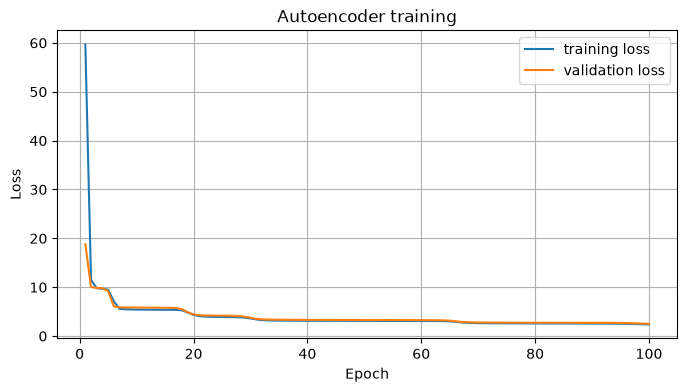

In [8]:
plot_loss(train_loss_1, val_loss_1)

Ticker: SPY
Ventana: 4121:4149
Real:


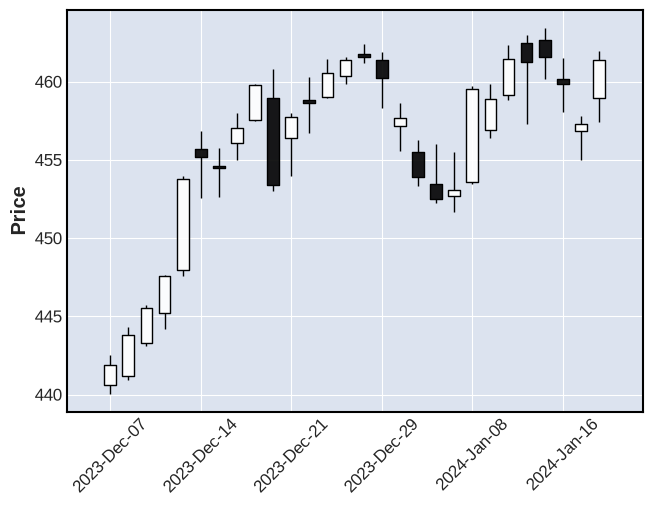

Reconstruction:


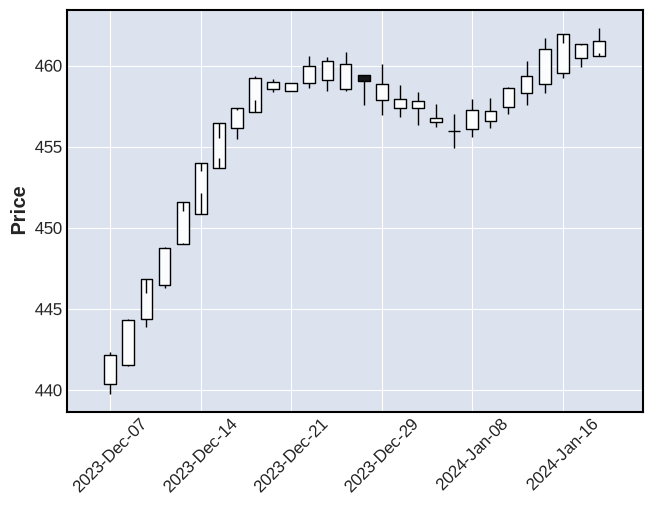

('SPY',
 4121,
 Price             Open        High         Low       Close
 Date                                                      
 2023-12-07  440.644890  442.564041  440.046966  441.917908
 2023-12-08  441.175389  444.348280  440.934289  443.817871
 2023-12-11  443.325985  445.717713  443.113815  445.544098
 2023-12-12  445.196905  447.675426  444.203572  447.578979
 2023-12-13  447.955094  454.001914  447.598270  453.751160
 2023-12-14  455.679914  456.866139  452.545608  455.207367
 2023-12-15  454.612819  455.784498  452.618099  454.457886
 2023-12-18  456.055602  457.992226  455.000145  457.014221
 2023-12-19  457.556506  459.870786  457.479054  459.793304
 2023-12-20  458.941237  460.819765  452.995815  453.421875
 2023-12-21  456.394548  457.992287  453.983461  457.721161
 2023-12-22  458.844390  460.316243  456.752861  458.641052
 2023-12-26  459.047717  461.478160  458.970235  460.577637
 2023-12-27  460.374330  461.555672  459.841770  461.410431
 2023-12-28  461.768637  

In [20]:
# This cell is meant to be run several times for checking eyeballing
# RUN THIS CELL SEVERAL TIMES!
random_compare(tickers_dfs, TICKERS, model_1, n_candles=N_CANDLES)

Looking at the validation error, looks like there is not an overfitting problem; but the model stoped learning well around epoch 20.

In [23]:
import importlib
import TrainingLoop
from TrainingLoop import train_autoencoder
importlib.reload(TrainingLoop)

# Lower learning rate and lower batch_size to scape from local minimums with more noise,
# but at lower steps.
train_params_2 = {
    "learning_rate": 2e-5,
    "batch_size": 64,
    "epochs": 100,
    "loss_fn": torch.nn.MSELoss(),
    "optimizer": torch.optim.Adam,
    "patience": 10  # for early stopping
}

model_1_2, train_loss_1_2, val_loss_1_2 = train_autoencoder(
    model=model_1,
    train_dataloader=DataLoader(
        train_dataset,
        batch_size=train_params_2["batch_size"],
        shuffle=True
    ),
    epochs=train_params_2["epochs"],
    loss_fn=train_params_2["loss_fn"],
    optimizer=train_params_2["optimizer"](
        params=model_1.parameters(),
        lr=train_params_2["learning_rate"]
    ),
    device=DEVICE,
    val_dataloader=DataLoader(
        val_dataset,
        batch_size=train_params_2["batch_size"],
        shuffle=False
    ),
    patience=train_params_2["patience"]
)

epoch: 100%|██████████| 100/100 [03:25<00:00,  2.06s/it, loss=2.0829e+00, lr=2.00e-05, val_loss=2.2560e+00]


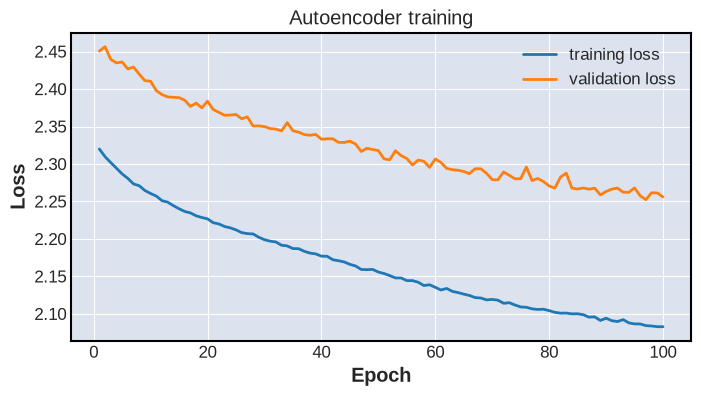

In [24]:
plot_loss(train_loss_1_2, val_loss_1_2)

Since the values are getting closer to 1, lets try to only modify the loss function to **L1** (absolute error).

Lets say the real value is $0.4$ and the prediction is $0.5$ (just one float value). Then, the L1 error is $0.1$, but the $MSE$ error is $0.01$ (lower). But this doesn't guarantees anything...

In [25]:
model_1_3, train_loss_1_3, val_loss_1_3 = train_autoencoder(
    model=model_1_2,
    train_dataloader=DataLoader(
        train_dataset,
        batch_size=train_params_2["batch_size"],
        shuffle=True
    ),
    epochs=train_params_2["epochs"],
    loss_fn=torch.nn.L1Loss(),
    optimizer=train_params_2["optimizer"](
        params=model_1_2.parameters(),
        lr=train_params_2["learning_rate"]
    ),
    device=DEVICE,
    val_dataloader=DataLoader(
        val_dataset,
        batch_size=train_params_2["batch_size"],
        shuffle=False
    ),
    patience=train_params_2["patience"]
)

epoch:  82%|████████▏ | 82/100 [02:52<00:37,  2.10s/it, loss=7.2971e-01, lr=2.00e-05, val_loss=7.4495e-01]

Early stopping at epoch 83


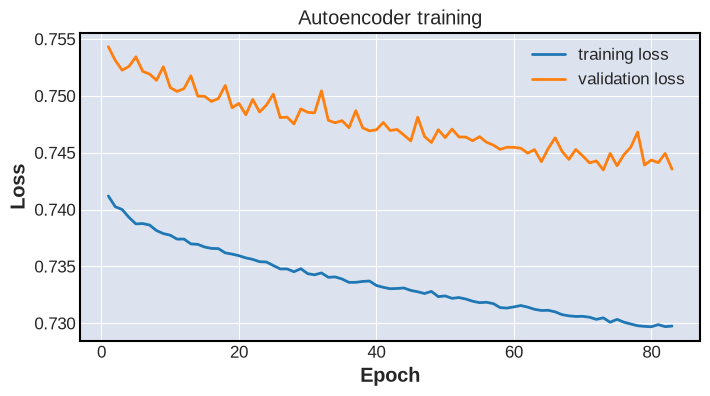

In [26]:
plot_loss(train_loss_1_3, val_loss_1_3)

<b style="color:red">Note:</b> at this point the `train_dataloader` and `val_dataloader` have been created several times, which is not very efficient... but useful to change the batch_size

In [ ]:
model_1_3.eval() # Useless because haven't use dropout for instance, but in case

mse = torch.nn.MSELoss()
l1 = torch.nn.L1Loss()

test_dataloader = DataLoader(
    test_dataset,
    batch_size=train_params_2["batch_size"],
    shuffle=False
)

mse_total = 0.0
l1_total = 0.0

with torch.no_grad():
    for x in test_dataloader:
        x = x.to(DEVICE)
        pred = model_1_3(x)

        mse_total += mse(pred, x).item()
        l1_total += l1(pred, x).item()

mse_loss = mse_total / len(test_dataloader)
l1_loss = l1_total / len(test_dataloader)

print(f"MSE: {mse_loss:.4f}")
print(f"L1:  {l1_loss:.4f}")

MSE: 2.0952
L1:  0.7324


Since these are not 1-Dimensional values, the MSE is larger although L1 $\le 1$.

Lets continue with MSELoss. But this time, with more epochs, since there is already an early-stopping criteria.

In [ ]:
model_1_3.train()

model_1_4, train_loss_1_4, val_loss_1_4 = train_autoencoder(
    model=model_1_3,
    train_dataloader=DataLoader(
        train_dataset,
        batch_size=train_params_2["batch_size"],
        shuffle=True
    ),
    epochs=300,
    loss_fn=train_params_2["loss_fn"],
    optimizer=train_params_2["optimizer"](
        params=model_1_2.parameters(),
        lr=train_params_2["learning_rate"]
    ),
    device=DEVICE,
    val_dataloader=DataLoader(
        val_dataset,
        batch_size=train_params_2["batch_size"],
        shuffle=False
    ),
    patience=train_params_2["patience"]
)

epoch:   6%|▌         | 18/300 [00:45<11:56,  2.54s/it, loss=2.0197e+00, lr=2.00e-05, val_loss=2.1885e+00]

Early stopping at epoch 19


In [31]:
mse_total = 0.0
l1_total = 0.0

with torch.no_grad():
    for x in test_dataloader:
        x = x.to(DEVICE)
        pred = model_1_4(x)

        mse_total += mse(pred, x).item()
        l1_total += l1(pred, x).item()

mse_loss = mse_total / len(test_dataloader)
l1_loss = l1_total / len(test_dataloader)

print(f"MSE: {mse_loss:.4f}")
print(f"L1:  {l1_loss:.4f}")

MSE: 2.0850
L1:  0.7371


Ticker: VTI
Ventana: 3940:3968
Real:


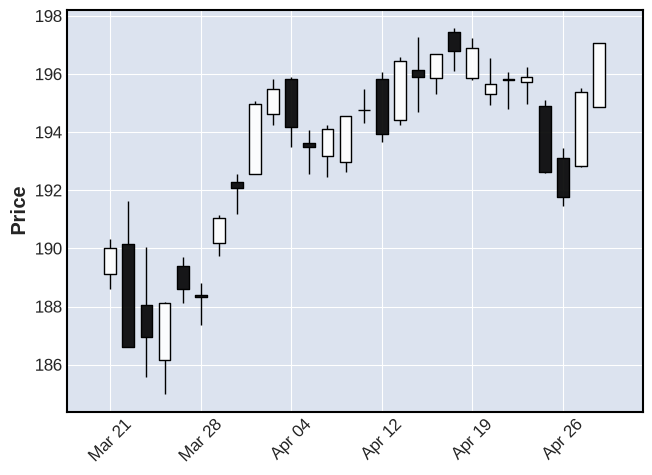

Reconstruction:


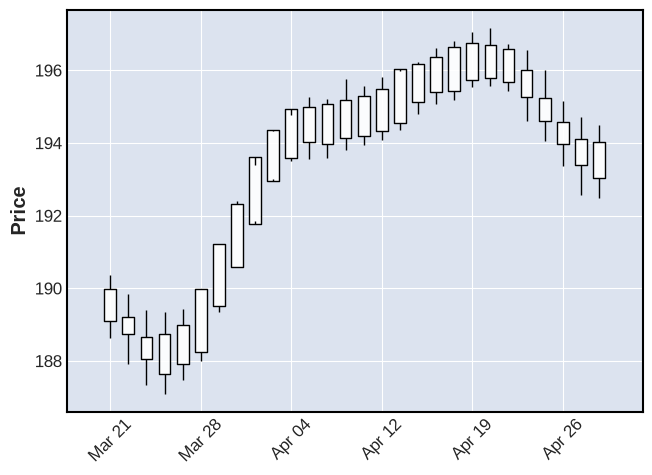

('VTI',
 3940,
 Price             Open        High         Low       Close
 Date                                                      
 2023-03-21  189.111731  190.339120  188.607460  190.006104
 2023-03-22  190.148829  191.633101  186.599882  186.609406
 2023-03-23  188.048081  190.054173  185.564331  186.949493
 2023-03-24  186.166141  188.162686  184.991129  188.124466
 2023-03-27  189.404563  189.719809  188.114921  188.602112
 2023-03-28  188.382392  188.812268  187.369792  188.334625
 2023-03-29  190.187887  191.143173  189.729354  191.047653
 2023-03-30  192.270415  192.576099  191.171828  192.079361
 2023-03-31  192.557005  195.059849  192.557005  194.973877
 2023-04-03  194.610854  195.824071  194.238293  195.489716
 2023-04-04  195.833641  195.890955  193.474083  194.181000
 2023-04-05  193.626909  194.075895  192.566541  193.474060
 2023-04-06  193.197054  194.247860  192.442370  194.114120
 2023-04-10  192.967765  194.572638  192.633409  194.553543
 2023-04-11  194.754150  

In [39]:
random_compare(tickers_dfs, TICKERS, model_1_4, n_candles=N_CANDLES)